
# 🌍 Climate & Health Risk Prediction Challenge - Starter Notebook (with Climate Enrichment)

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a recorded death falls into a **climate-sensitive category**.

This notebook shows a baseline workflow that combines:

- the main competition data (`Train.csv`, `Test.csv`)
- the downloaded climate and environmental features (`climate_features_rich.csv`)

The notebook covers:

- Loading and merging the datasets
- Exploratory data analysis
- Preprocessing and feature engineering
- Training a baseline classifier
- Evaluating with the official metric:
  - **Final Score = 0.60 × F1 + 0.40 × ROC-AUC**
- Creating a submission file with the required columns:
  - `ID`
  - `TargetF1`
  - `TargetRAUC`

This notebook is designed to be beginner-friendly. You are encouraged to improve it with stronger models, richer feature engineering, and better validation.


In [24]:

# 📚 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


In [5]:

# 📥 Load the main competition data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

# 📥 Load downloaded climate/environmental features
# This file should contain one row per ID
climate_features = pd.read_csv("climate_features.csv")

ID_COL = "ID"
TARGET = "is_climate_sensitive"
TARGET_F1 = "TargetF1"
TARGET_RAUC = "TargetRAUC"

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Climate feature shape:", climate_features.shape)

train.head()


Train shape: (3146, 13)
Test shape: (1030, 12)
Climate feature shape: (4176, 18)


,ID,zone,gender,deathdate,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive
0,ID_1FE951BD,Rural,Male,2007-10-02,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1
1,ID_5927A443,Rural,Male,2008-01-05,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
2,ID_C4E67025,Rural,Female,2008-02-14,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1
3,ID_44DC5CE9,Rural,Female,2008-02-15,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1
4,ID_33C677BB,Rural,Female,2008-02-15,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0



## 🔗 Merge climate features

We merge the downloaded climate and environmental features back into the training and test data using `ID`.


In [6]:
## Drop deathdate from climate_features
climate_features = climate_features.drop(columns=["deathdate"])

In [7]:

# Merge on ID
train = train.merge(climate_features, on=ID_COL, how="left")
test = test.merge(climate_features, on=ID_COL, how="left")

print("Train shape after merge:", train.shape)
print("Test shape after merge:", test.shape)

# Create a sample submission template from the test IDs
sample_submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: 0,
    TARGET_RAUC: 0.5
})

sample_submission.head()


Train shape after merge: (3146, 29)
Test shape after merge: (1030, 28)


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.5
1,ID_6EDEA907,0,0.5
2,ID_B9FFC8D8,0,0.5
3,ID_74C6C94E,0,0.5
4,ID_0E02825D,0,0.5



## 🔍 Exploratory Data Analysis (EDA)

Let’s inspect the merged training data, check missing values, and understand the target distribution.


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3146 entries, 0 to 3145
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    3146 non-null   object 
 1   zone                  3146 non-null   object 
 2   gender                3146 non-null   object 
 3   deathdate             3146 non-null   object 
 4   age                   3146 non-null   float64
 5   avg_temperature       3146 non-null   float64
 6   max_temperature       3146 non-null   float64
 7   min_temperature       3146 non-null   float64
 8   precipitation         3146 non-null   float64
 9   latitude              3146 non-null   float64
 10  longitude             3146 non-null   float64
 11  location              3146 non-null   object 
 12  is_climate_sensitive  3146 non-null   int64  
 13  elevation             3146 non-null   int64  
 14  hot_days_30d          3146 non-null   int64  
 15  max_daily_rain_30d   

In [9]:

# Missing values summary
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(30)


,0


In [10]:

# Target distribution
train[TARGET].value_counts(normalize=True)


,proportion
is_climate_sensitive,
1,0.650668
0,0.349332


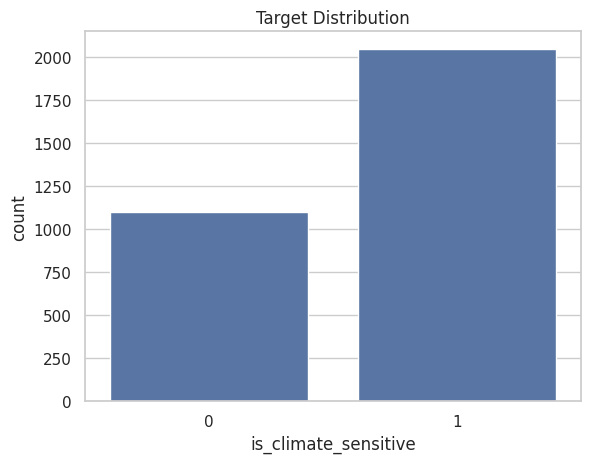

In [11]:

sns.countplot(x=TARGET, data=train)
plt.title("Target Distribution")
plt.show()


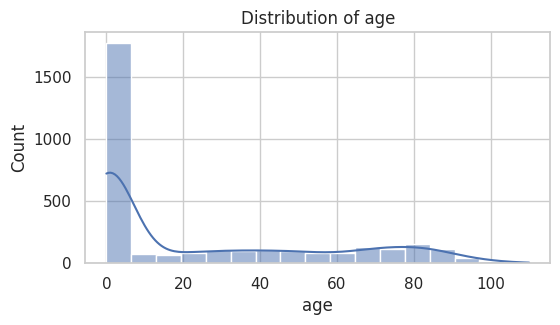

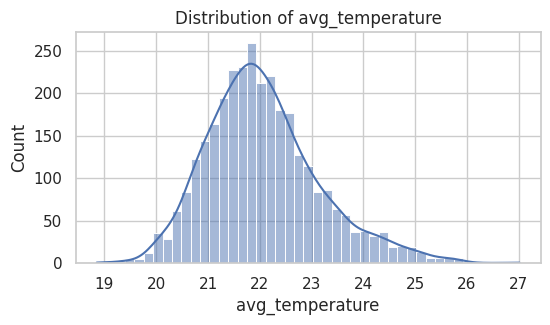

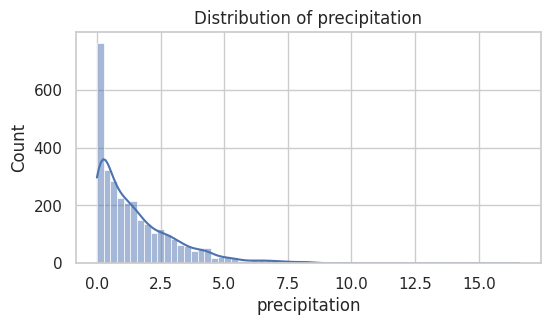

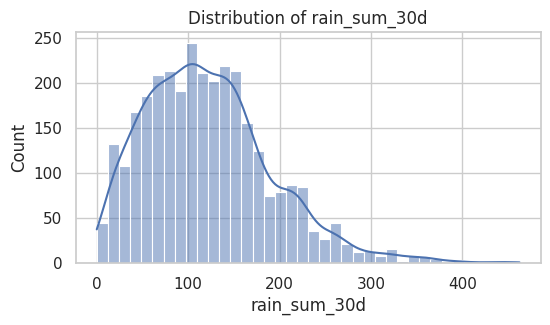

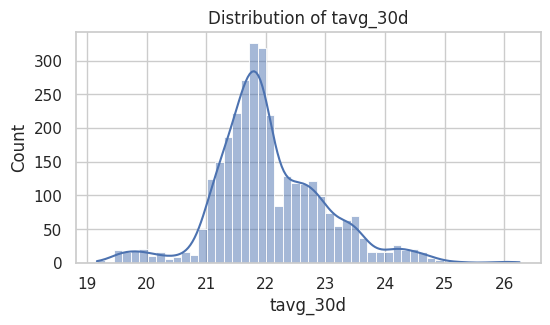

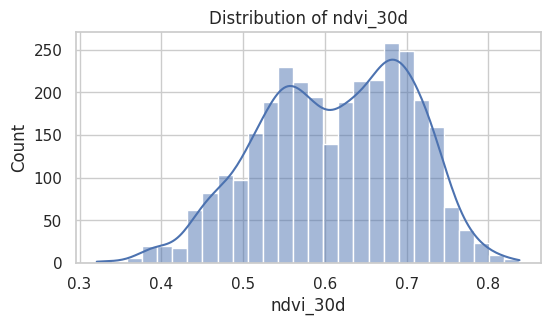

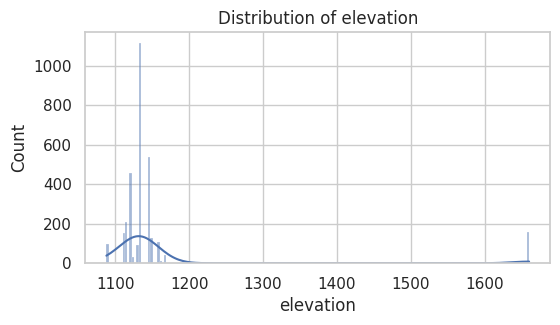

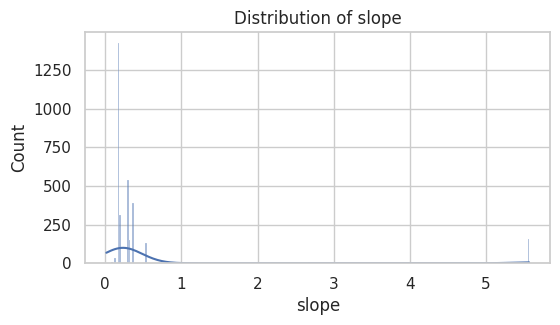

In [12]:

# Inspect some original and downloaded climate features
features_to_plot = [
    "age",
    "avg_temperature",
    "precipitation",
    "rain_sum_30d",
    "tavg_30d",
    "ndvi_30d",
    "elevation",
    "slope"
]

for col in features_to_plot:
    if col in train.columns:
        plt.figure(figsize=(6, 3))
        sns.histplot(train[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()



## 🧹 Preprocessing and feature engineering

We keep the baseline simple and use:

- the original challenge features
- the downloaded climate/environmental features
- a few easy engineered features from `deathdate`


In [13]:

train_df = train.copy()
test_df = test.copy()

# Convert dates
train_df["deathdate"] = pd.to_datetime(train_df["deathdate"], errors="coerce")
test_df["deathdate"] = pd.to_datetime(test_df["deathdate"], errors="coerce")

# Simple date features
for df_ in [train_df, test_df]:
    df_["day_of_year"] = df_["deathdate"].dt.dayofyear
    df_["temperature_range"] = df_["max_temperature"] - df_["min_temperature"]
    df_["is_rainy_day_current"] = (df_["precipitation"] > 0).astype(int)

# Drop raw date after feature extraction
train_df = train_df.drop(columns=["deathdate"])
test_df = test_df.drop(columns=["deathdate"])

train_df.head()


,ID,zone,gender,age,avg_temperature,max_temperature,min_temperature,precipitation,latitude,longitude,location,is_climate_sensitive,elevation,hot_days_30d,max_daily_rain_30d,ndvi_30d,ndvi_90d,rain_days_30d,rain_sum_30d,rain_sum_7d,rain_sum_90d,slope,tavg_30d,tavg_7d,tavg_90d,temp_range_mean_30d,tmax_30d,tmin_30d,day_of_year,temperature_range,is_rainy_day_current
0,ID_1FE951BD,Rural,Male,30.0,21.137037,25.569017,18.451642,0.951601,0.584646,33.546344,"Izimba, Iganga, Uganda",1,1114,0,20.394434,0.72205,0.72910,18,175.264057,28.419111,421.992750,0.168545,21.425953,22.012127,21.043539,7.897970,27.608331,16.132043,275,7.117375,1
1,ID_5927A443,Rural,Male,2.0,24.062790,29.312026,18.977212,0.053352,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,1145,0,16.994602,0.60815,0.66985,7,71.885960,0.000000,268.439276,0.299996,22.129209,23.021381,21.992129,8.735769,29.251932,15.591455,5,10.334814,1
2,ID_C4E67025,Rural,Female,31.0,22.407868,26.746058,18.112977,0.090349,0.573420,33.483655,"Buluza, Iganga, Uganda",1,1145,0,15.661628,0.59290,0.61335,20,108.145379,35.970423,242.081887,0.299996,21.990516,21.557252,22.220307,7.694241,29.083597,17.420068,45,8.633080,1
3,ID_44DC5CE9,Rural,Female,1.0,23.315198,28.056889,18.955708,0.286814,0.549565,33.490326,"Nawanzu, Iganga, Uganda",1,1145,0,15.661628,0.59290,0.61335,19,98.524518,29.091067,229.370640,0.299996,22.032392,21.693581,22.231408,7.718027,29.083597,17.420068,46,9.101181,1
4,ID_33C677BB,Rural,Female,69.0,23.315198,28.056889,18.955708,0.286814,1.072343,34.226647,"Magada, Mbale City, Bugisa sub-region, Eastern...",0,1660,0,13.468142,0.53380,0.71580,13,84.030272,25.698621,186.079130,5.565486,20.143552,20.141416,20.510054,10.152887,28.300394,12.632257,46,9.101181,1


In [14]:

# Define target and features
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET]

X_test = test_df.drop(columns=[ID_COL])

categorical_features = [c for c in X.columns if X[c].dtype == "object"]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("\nNumber of numeric features:", len(numeric_features))
print("\nA few numeric features:", numeric_features[:20])


Categorical features: ['zone', 'gender', 'location']

Number of numeric features: 26

A few numeric features: ['age', 'avg_temperature', 'max_temperature', 'min_temperature', 'precipitation', 'latitude', 'longitude', 'elevation', 'hot_days_30d', 'max_daily_rain_30d', 'ndvi_30d', 'ndvi_90d', 'rain_days_30d', 'rain_sum_30d', 'rain_sum_7d', 'rain_sum_90d', 'slope', 'tavg_30d', 'tavg_7d', 'tavg_90d']



## ✂️ Train / Validation Split

We create a validation set to estimate baseline performance before generating a submission.


In [15]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


X_train shape: (2516, 29)
X_val shape: (630, 29)



## 🤖 Baseline Model

We use Logistic Regression as a simple and interpretable baseline.

Because the challenge metric includes both **F1** and **ROC-AUC**, this is a good baseline model to start with before trying stronger methods such as Random Forest, LightGBM, XGBoost, or CatBoost.


In [16]:
## Drop location from categorical features
categorical_features.remove("location")
categorical_features

['zone', 'gender']

In [17]:
## Check if latitude and longitude are in numerical features and drop them
numeric_features.remove("latitude")
numeric_features.remove("longitude")
numeric_features

['age',
 'avg_temperature',
 'max_temperature',
 'min_temperature',
 'precipitation',
 'elevation',
 'hot_days_30d',
 'max_daily_rain_30d',
 'ndvi_30d',
 'ndvi_90d',
 'rain_days_30d',
 'rain_sum_30d',
 'rain_sum_7d',
 'rain_sum_90d',
 'slope',
 'tavg_30d',
 'tavg_7d',
 'tavg_90d',
 'temp_range_mean_30d',
 'tmax_30d',
 'tmin_30d',
 'day_of_year',
 'temperature_range',
 'is_rainy_day_current']

In [26]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        )
    ]
)

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['zone', 'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_temperature',
                                                   'max_temperature',
                                                   '...
                                                   'precipitation', 'elevation',
                                                   'hot_days_30d',
                                                   'max_daily_rain_30d',
                                                   'ndvi_30d', 'ndvi_90d',
                                                   'rain_days_30d',
                                                   'rain_sum_30d',
                                                   'rain_sum_7d',
                                                   'rain_sum_90d', 'slope',
                                                   'tavg_30d', 'tavg_7d',
                                                   'tavg_90d',
                                                   'temp_range_mean_30d',
                                                   'tmax_30d', 'tmin_30d',
                                                   'day_of_year',
                                                   'temperature_range',
                                                   'is_rainy_day_current'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])


## 📈 Validation Performance

Official metric:

**Final Score = 0.60 × F1 + 0.40 × ROC-AUC**

Participants submit:
- `TargetF1`: binary prediction
- `TargetRAUC`: probability prediction


In [27]:

# Validation predictions
val_pred_proba = pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_proba >= 0.5).astype(int)

f1 = f1_score(y_val, val_pred_label)
auc = roc_auc_score(y_val, val_pred_proba)
final_score = 0.60 * f1 + 0.40 * auc

print(f"Validation F1-score: {f1:.6f}")
print(f"Validation ROC-AUC:  {auc:.6f}")
print(f"Validation Final Score: {final_score:.6f}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred_label, digits=3))


Validation F1-score: 0.801944
Validation ROC-AUC:  0.781746
Validation Final Score: 0.793865

Classification Report:
              precision    recall  f1-score   support

           0      0.631     0.623     0.627       220
           1      0.799     0.805     0.802       410

    accuracy                          0.741       630
   macro avg      0.715     0.714     0.714       630
weighted avg      0.740     0.741     0.741       630



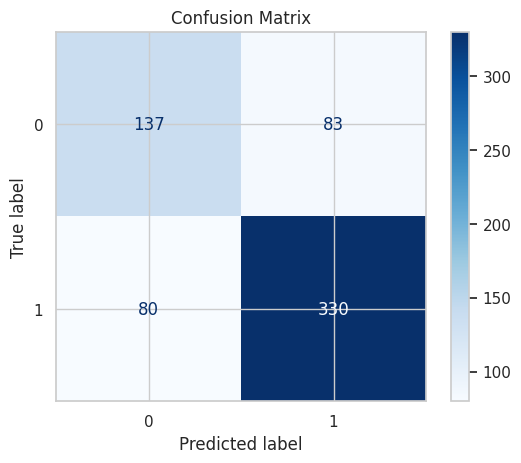

In [28]:

cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



## 📊 Feature Importance

We use permutation importance to see which features are most helpful to the baseline model.


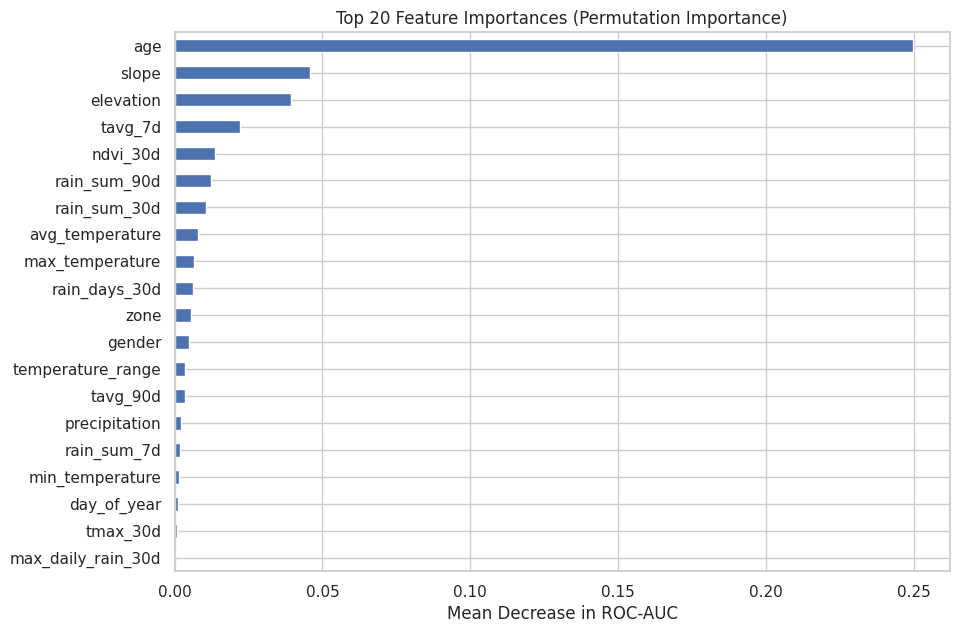

In [29]:

result = permutation_importance(
    pipeline,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="roc_auc"
)

importances = pd.Series(result.importances_mean, index=X.columns)

(
    importances
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
    .plot(kind="barh", figsize=(10, 7))
)

plt.title("Top 20 Feature Importances (Permutation Importance)")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.show()



## 🚀 Train on Full Data and Predict on Test

Now retrain the baseline on the full training data and generate the submission file.


In [30]:

pipeline.fit(X, y)

test_pred_proba = pipeline.predict_proba(X_test)[:, 1]
test_pred_label = (test_pred_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET_F1: test_pred_label,
    TARGET_RAUC: test_pred_proba
})

submission.head()


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.192852
1,ID_6EDEA907,0,0.411029
2,ID_B9FFC8D8,0,0.239403
3,ID_74C6C94E,1,0.755378
4,ID_0E02825D,1,0.698908


In [31]:

submission.to_csv("starter_submission.csv", index=False)
print("Submission file saved as starter_submission.csv")


Submission file saved as starter_submission.csv



## ✅ What’s Next?

This is still only a starter baseline. You can improve it by:

- trying stronger models such as Random Forest, LightGBM, XGBoost, or CatBoost
- tuning the threshold used for `TargetF1`
- engineering richer spatial features
- comparing models with and without downloaded climate features
- validating more carefully across space

Good luck, and happy modelling! 🚀
